The goal of this task is to predict the continuous median house value (MedHouseVal) for various districts in California.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

california = fetch_california_housing(as_frame=True)
df_cal = california.frame

# Display the size of the dataset and the first few rows
print(f"Data Shape (Rows, Columns): {df_cal.shape}\n")
display(df_cal.head())

Data Shape (Rows, Columns): (20640, 9)



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Data Cleaning & Preprocessing

In [2]:
# Check for missing values in every column
missing_values = df_cal.isnull().sum()
print("Missing Values per Column:\n", missing_values)

Missing Values per Column:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


Exploratory Data Analysis (EDA) & Visualizations

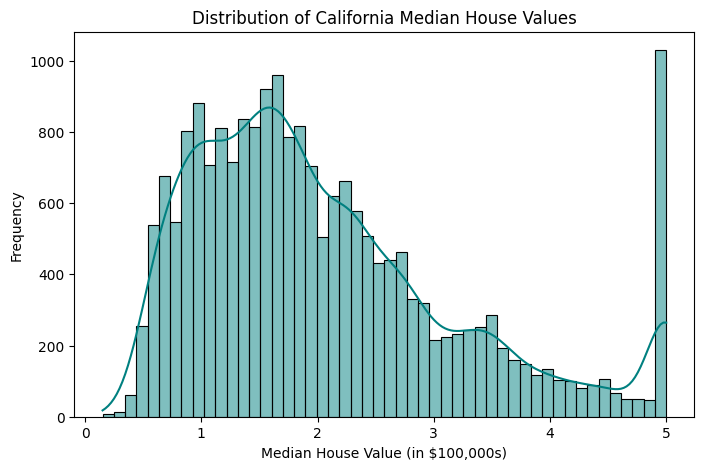

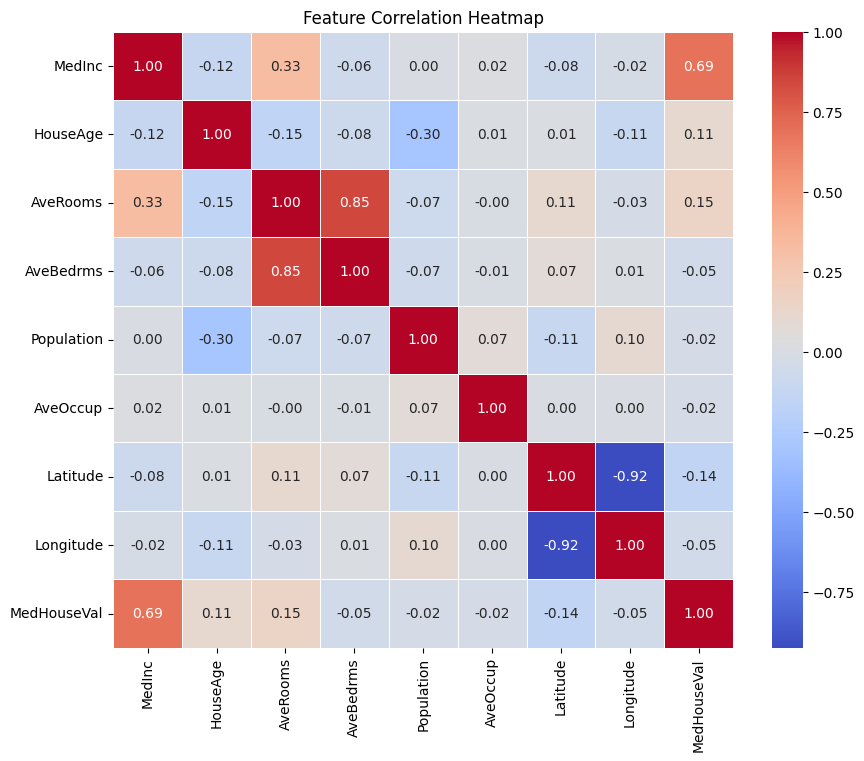

In [3]:
# 1. Histogram of the Target Variable
plt.figure(figsize=(8, 5))
sns.histplot(df_cal['MedHouseVal'], bins=50, kde=True, color='teal')
plt.title('Distribution of California Median House Values')
plt.xlabel('Median House Value (in $100,000s)')
plt.ylabel('Frequency')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
# We calculate the correlation matrix and visualize it
correlation_matrix = df_cal.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

Key Insights from EDA
* zero missing values in this dataset, so no imputation (filling in blanks) is required.
* The median house values are mostly concentrated between 1.0 and 3.0 However, there is a weird, artificial spike right at 5.0 ($500k).

* Looking at the heatmap, MedInc (Median Income) has the strongest positive correlation (0.69) with MedHouseVal. This makes logical sense: areas where people earn more money tend to have more expensive homes.

Model Training & Evaluation
* We will use an 80/20 train-test split.

I will evaluate it using:
* RMSE (Root Mean Squared Error): The average error in the predicted house prices.
* R-squared ($R^2$): How much of the variance in house prices the model successfully explains.

In [8]:
# 1. Separate features (X) from the target (y)
X = df_cal.drop('MedHouseVal', axis=1)
y = df_cal['MedHouseVal']

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make predictions on the test set
predictions = model.predict(X_test)

# 5. Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("--- Linear Regression Results ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} ")
print(f"R-squared (R2) Score: {r2:.4f}")

--- Linear Regression Results ---
Root Mean Squared Error (RMSE): 0.7456 
R-squared (R2) Score: 0.5758


In [9]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train a Decision Tree instead of a straight line
# We set a max_depth so the tree doesn't overfit and memorize the data
tree_model = DecisionTreeRegressor(max_depth=9, random_state=42)
tree_model.fit(X_train, y_train)

# Make predictions
tree_preds = tree_model.predict(X_test)

# Evaluate
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_preds))
tree_r2 = r2_score(y_test, tree_preds)

print("--- Decision Tree Results ---")
print(f"Root Mean Squared Error (RMSE): {tree_rmse:.4f}")
print(f"R-squared (R2) Score: {tree_r2:.4f}")

--- Decision Tree Results ---
Root Mean Squared Error (RMSE): 0.6443
R-squared (R2) Score: 0.6833
